This notebook  investigates flood events from the top 37 sites identified by the Log_Pearson3 having a flood severity score of 1.25 or higher. 

In [3]:
import json
from pathlib import Path
import polars as pl
import wandb
import numpy as np
import os
import gc
import re

# Build path relative to the notebook location
json_path = Path("../../src/static/top_site_quantile_thresholds.json")

with open(json_path, "r") as f:
    quantile_thresholds = json.load(f)

site_list = list(quantile_thresholds.keys())

print(f"Number of sites: {len(site_list)}")
print(f"First few sites: {site_list[:5]}")

Number of sites: 37
First few sites: ['06803500', '06446700', '06793000', '06465700', '06799100']


In [5]:
# Download artifact to get artifact_dir
api = wandb.Api()
artifact = api.artifact("flood-forecasting/raw-streamflow-15min:latest")
artifact_dir = artifact.download()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\mroth\.netrc.
wandb: Downloading large artifact 'raw-streamflow-15min:latest', 1467.48MB. 20 files...
wandb:   20 of 20 files downloaded.  
Done. 00:00:01.0 (1428.6MB/s)


In [36]:
from datetime import timedelta

sf15_lazy = pl.scan_parquet(os.path.join(artifact_dir, "streamflow_15min", "*.parquet"))

event_records = []

for site_id in site_list:
    thresholds = quantile_thresholds[site_id]
    q2 = thresholds["Q2_cfs"]
    q2_half = q2 / 2
    quantile_order = ["Q100_cfs", "Q50_cfs", "Q25_cfs", "Q10_cfs", "Q5_cfs", "Q2_cfs"]

    # Pull FULL time series (not pre-filtered) to detect Q2 crossings
    site_df = (
        sf15_lazy
        .filter(pl.col("site_id") == site_id)
        .filter(pl.col("streamflow_cfs").is_not_null())
        .select(["site_id", "datetime", "streamflow_cfs"])
        .sort("datetime")
        .collect()
        .with_columns(pl.col("datetime").cast(pl.Datetime))
    )

    if site_df.is_empty():
        continue

    datetimes = site_df["datetime"].to_list()
    flows = site_df["streamflow_cfs"].to_list()

    # Step 1: Group into contiguous exceedance blocks
    # Block starts when flow >= Q2, breaks only when flow drops below Q2/2
    exceedance_blocks = []
    current_block = []

    for i in range(len(datetimes)):
        if flows[i] >= q2:
            current_block.append(i)
        elif current_block and flows[i] >= q2_half:
            # Still above half-Q2 — treat as continuation of the flood
            current_block.append(i)
        else:
            if current_block:
                exceedance_blocks.append(current_block)
                current_block = []
    if current_block:
        exceedance_blocks.append(current_block)

    # Step 2: Apply 48-hour separation between distinct blocks
    # If two blocks have peaks within 48 hours of each other, merge them
    def get_peak(block):
        return max(block, key=lambda j: flows[j])

    merged_blocks = []
    for block in exceedance_blocks:
        if not merged_blocks:
            merged_blocks.append(block)
        else:
            prev_peak_dt = datetimes[get_peak(merged_blocks[-1])]
            curr_peak_dt = datetimes[get_peak(block)]
            if abs((curr_peak_dt - prev_peak_dt).total_seconds()) <= 48 * 3600:
                # Merge into the previous block
                merged_blocks[-1] = merged_blocks[-1] + block
            else:
                merged_blocks.append(block)

    # Step 3: Find peak in each merged block and classify
    events = []
    for block in merged_blocks:
        peak_idx = get_peak(block)
        peak_flow = flows[peak_idx]
        peak_dt = datetimes[peak_idx]

        classification = None
        for q in quantile_order:
            if peak_flow >= thresholds[q]:
                classification = q.replace("_cfs", "")
                break

        events.append({
            "site_id": site_id,
            "datetime": peak_dt,
            "streamflow_cfs": peak_flow,
            "classification": classification
        })

    event_records.extend(events)
    print(f"  {site_id}: {len(events)} events found")

events_df = pl.DataFrame(event_records)
print(f"\nTotal events: {len(events_df)}")
print(events_df.head(10))


  06803500: 15 events found
  06446700: 18 events found
  06793000: 23 events found
  06465700: 9 events found
  06799100: 24 events found
  06917000: 14 events found
  06820500: 17 events found
  06838000: 12 events found
  06803495: 14 events found
  06700000: 10 events found
  06449000: 15 events found
  06036650: 11 events found
  06710385: 11 events found
  06440200: 24 events found
  06207500: 11 events found
  06447500: 21 events found
  06784000: 26 events found
  06892000: 14 events found
  06464100: 13 events found
  06188000: 10 events found
  06821500: 26 events found
  06803513: 14 events found
  06061500: 12 events found
  06935955: 11 events found
  06895000: 14 events found
  06799315: 17 events found
  06881000: 12 events found
  06935755: 16 events found
  06921590: 15 events found
  06917060: 10 events found
  06211000: 15 events found
  06869950: 17 events found
  06308500: 15 events found
  06093200: 12 events found
  06450500: 13 events found
  06909500: 9 events 

In [37]:
# Save the results to a csv file to the hard drive.
events_df.write_csv(r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project\peak_events.csv")

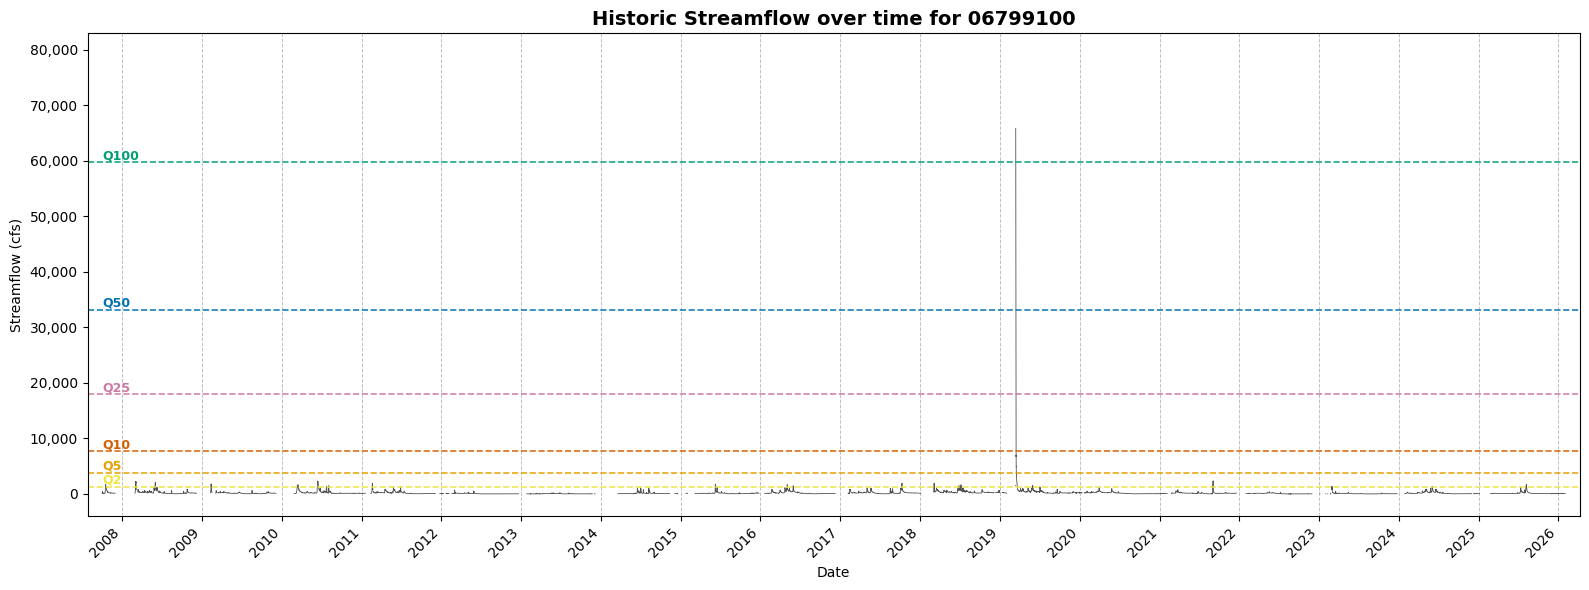

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

site_id = "06799100"
thresholds = quantile_thresholds[site_id]

# Pull full streamflow record for this site
site_df = (
    sf15_lazy
    .filter(pl.col("site_id") == site_id)
    .select(["datetime", "streamflow_cfs"])
    .sort("datetime")
    .collect()
)

datetimes = site_df["datetime"].to_list()
flows = [f if f is not None else float('nan') for f in site_df["streamflow_cfs"].to_list()]

# Quantile lines: label, value, color
quantile_styles = [
    ("Q2",   thresholds["Q2_cfs"],   "#f0e442"),
    ("Q5",   thresholds["Q5_cfs"],   "#e69f00"),
    ("Q10",  thresholds["Q10_cfs"],  "#d55e00"),
    ("Q25",  thresholds["Q25_cfs"],  "#cc79a7"),
    ("Q50",  thresholds["Q50_cfs"],  "#0072b2"),
    ("Q100", thresholds["Q100_cfs"], "#009e73"),
]

fig, ax = plt.subplots(figsize=(16, 6))

# Plot streamflow
ax.plot(datetimes, flows, color="#333333", linewidth=0.6, alpha=0.85, label="Streamflow")

# Plot quantile thresholds
for label, value, color in quantile_styles:
    ax.axhline(y=value, color=color, linestyle="--", linewidth=1.2, alpha=0.9)
    ax.text(
        x=datetimes[0],
        y=value,
        s=label,
        color=color,
        fontsize=9,
        fontweight="bold",
        va="bottom",
        ha="left"
    )

ax.set_title(f"Historic Streamflow over time for {site_id}", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (cfs)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.margins(x=0.01)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="x", which="major", linestyle="--", linewidth=0.7, alpha=0.5, color="gray")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [34]:
from datetime import datetime, timezone

def plot_streamflow(site_id: str, start_dt: datetime, end_dt: datetime):
    thresholds = quantile_thresholds[site_id]

    # Ensure datetimes are UTC-aware to match parquet column type
    if start_dt.tzinfo is None:
        start_dt = start_dt.replace(tzinfo=timezone.utc)
    if end_dt.tzinfo is None:
        end_dt = end_dt.replace(tzinfo=timezone.utc)

    site_df = (
        sf15_lazy
        .filter(pl.col("site_id") == site_id)
        .filter(pl.col("datetime").is_between(start_dt, end_dt))
        .select(["datetime", "streamflow_cfs"])
        .sort("datetime")
        .collect()
    )

    if site_df.is_empty():
        print(f"No data found for site {site_id} between {start_dt} and {end_dt}")
        return

    datetimes = site_df["datetime"].to_list()
    flows = [f if f is not None else float('nan') for f in site_df["streamflow_cfs"].to_list()]

    quantile_styles = [
        ("Q2",   thresholds["Q2_cfs"],   "#f0e442"),
        ("Q5",   thresholds["Q5_cfs"],   "#e69f00"),
        ("Q10",  thresholds["Q10_cfs"],  "#d55e00"),
        ("Q25",  thresholds["Q25_cfs"],  "#cc79a7"),
        ("Q50",  thresholds["Q50_cfs"],  "#0072b2"),
        ("Q100", thresholds["Q100_cfs"], "#009e73"),
    ]

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(datetimes, flows, color="#333333", linewidth=0.6, alpha=0.85, label="Streamflow")

    for label, value, color in quantile_styles:
        ax.axhline(y=value, color=color, linestyle="--", linewidth=1.2, alpha=0.9)
        ax.text(
            x=datetimes[0],
            y=value,
            s=label,
            color=color,
            fontsize=9,
            fontweight="bold",
            va="bottom",
            ha="left"
        )

    ax.set_title(f"Historic Streamflow over time for {site_id}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Streamflow (cfs)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.margins(x=0.01)

    # Scale x-axis ticks to the date range
    date_range_days = (end_dt - start_dt).days
    if date_range_days <= 30:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    elif date_range_days <= 90:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    elif date_range_days <= 365:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=30))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Y"))
    else:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=365))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.grid(axis="x", which="major", linestyle="--", linewidth=0.7, alpha=0.5, color="gray")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()




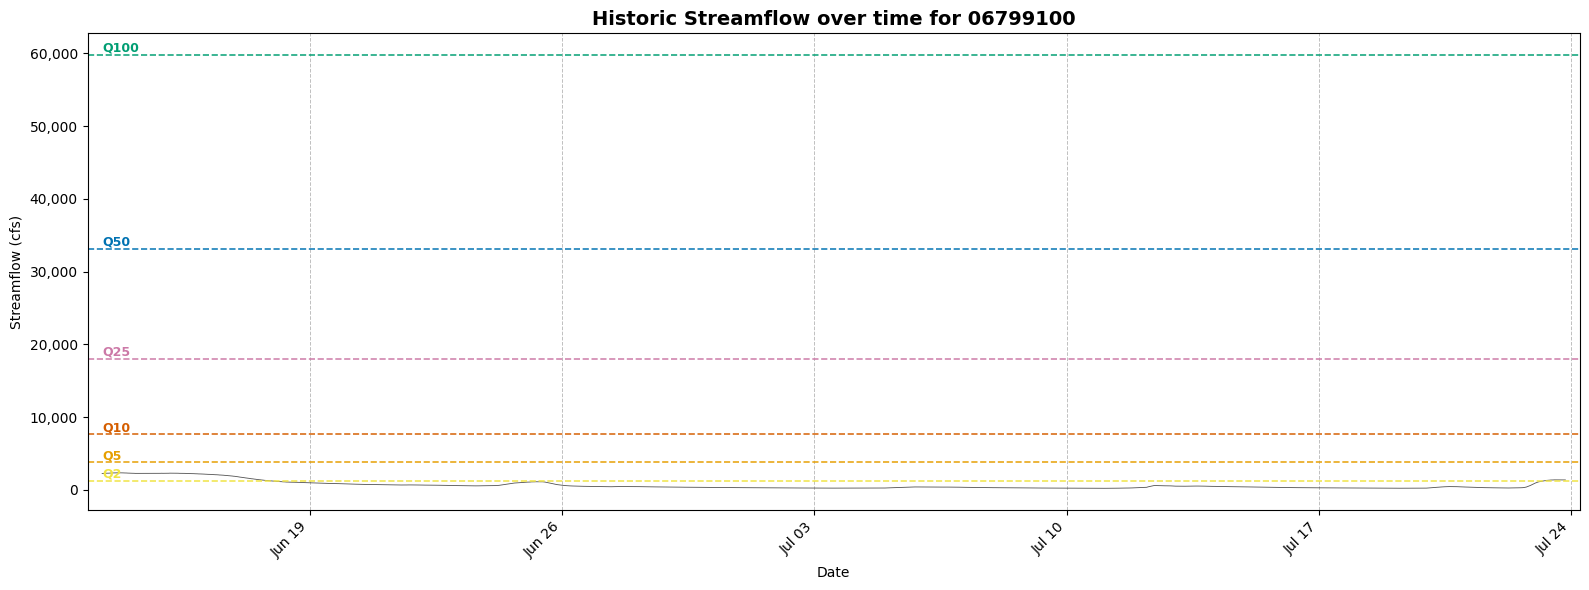

In [39]:
from datetime import datetime

# Plot example streamflow for site_id from a date range
start_dt = datetime.fromisoformat("2010-06-13T05:45:00.000000")
end_dt   = datetime.fromisoformat("2010-07-23T20:00:00.000000")

plot_streamflow("06799100", start_dt, end_dt)